# Why these study periods? Northern-China archival material density

Historical drought/flood grades are only as reliable as the documentary material (local
gazetteers, 方志) behind them. This notebook plots the **number of Northern-China gazetteer
works (部数) per decade**, with the **national average across the four regions** as a faint
grey reference, and the **Ming / Qing dynastic transition** marked.

The figure shows that documentation is sparse before ~1470 (0–1 work per decade), becomes
usable through the late Ming, and surges with Qing consolidation after 1644 — staying dense
through 1900. This motivates the **1470–1900** study window before the analysis hands off to
instrumental data (1901–2000).

Source: `data/旱涝图集资料统计.xlsx` (Sheet1).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

import os

import numpy as np
import pandas as pd
from hydra import compose, initialize

from shifting_baseline.utils.log import adjust_log_level, get_logger

with initialize(version_base=None, config_path="../config"):
    cfg = compose(config_name="config.yaml")
os.chdir(cfg.ds.root)  # cwd -> repo root, so data/ and reports/ are reachable

log = get_logger()
adjust_log_level(console_level="INFO", file_level="DEBUG")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from mksci_font import config_font

from shifting_baseline.constants import END, STAGE1

sns.set_style("ticks")
sns.set_context("paper")
config_font({"font.size": 9})

/Users/songshgeo/Documents/CodeBase/Scholar/shifting_baseline/.venv/lib/python3.11/site-packages/mksci_font/font_wrapper.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load and tidy the data

Row 0 of Sheet1 is a unit header (部/卷); we drop it and keep the decade year plus the
**部数 (number of works)** column for each of the four regions. The Northern-China series is
this study's focus; the mean across all four regions gives a national-average reference.

In [3]:
cols = {
    "北方地区方志部数": "north",
    "长江中下游地区方志部数": "yangtze",
    "华南地区方志部数": "south",
    "西南地区方志部数": "sw",
}
raw = pd.read_excel("data/旱涝图集资料统计.xlsx", sheet_name="Sheet1", skiprows=[1])
df = (
    raw[["年份", *cols]]
    .rename(columns={"年份": "year", **cols})
    .dropna(subset=["year"])
    .astype({"year": int, **{v: int for v in cols.values()}})
    .reset_index(drop=True)
)
df["natl_avg"] = df[list(cols.values())].mean(axis=1)

log.info(
    "Decades %d-%d | Northern works total = %d | pre-1470 max = %d/decade",
    df["year"].min(),
    df["year"].max(),
    df["north"].sum(),
    df.loc[df["year"] < 1470, "north"].max(),
)
df.head()

INFO | Decades 1370-1900 | Northern works total = 1707 | pre-1470 max = 1/decade


,year,north,yangtze,south,sw,natl_avg
0,1370,0,0,0,0,0.00
1,1380,0,1,0,0,0.25
2,1390,0,0,0,0,0.00
3,1400,0,1,0,0,0.25
4,1410,1,1,0,0,0.50


## Figure: decadal documentation density

Northern-China works are coloured by dynasty (Ming before 1644, Qing after); the national
average across the four regions is shown as faint grey reference bars. The shaded band marks
the 1470–1900 study window; the dotted line marks the Ming→Qing transition (1644). Records
before 1470 are genuinely sparse (0–1 work per decade), hence the near-empty left edge.

<BarContainer object of 54 artists>

<BarContainer object of 54 artists>

(0.0, 194.48000000000002)

(1362.0, 1908.0)

Text(1505, 181.61, 'Ming dynasty')

...

Text(1644, 170.17, '1644')

Text(1685.0, 155.15500000000003, 'Study window 1470–1900')

Text(1373, 71.5, 'Records before 1470 are sparse\n(0–1 work / decade)')

Text(0.5, 0, 'Decade')

Text(0, 0.5, 'Gazetteer works per decade')

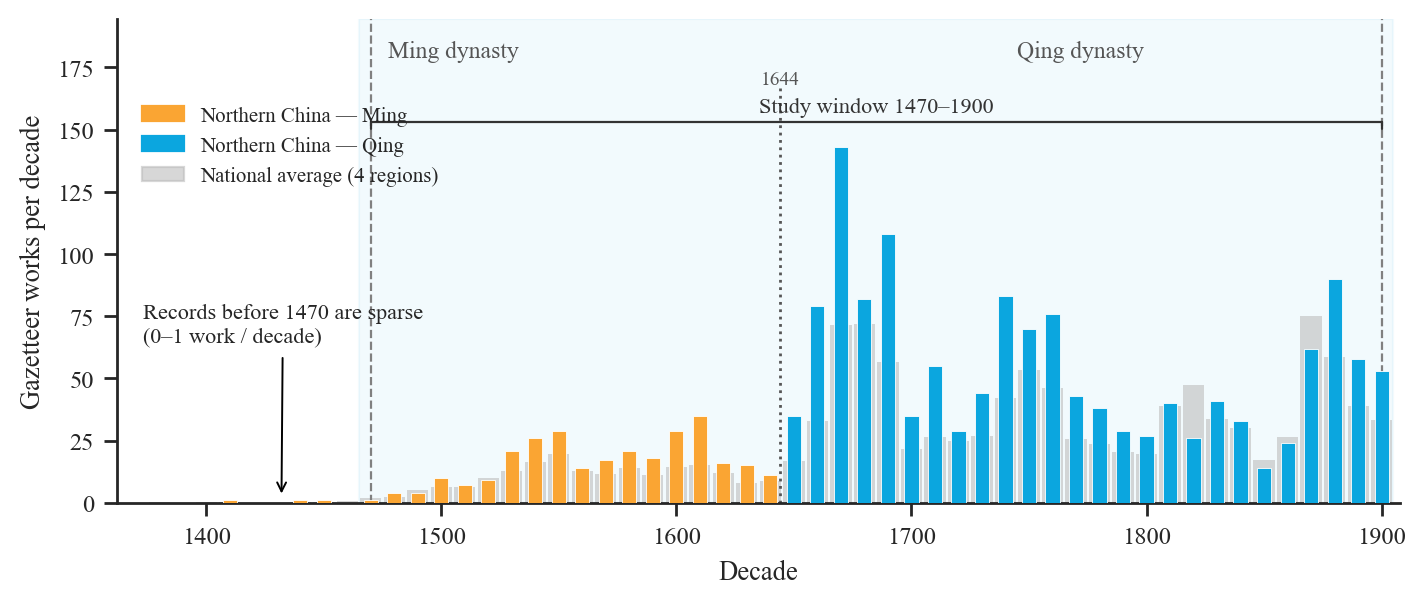

In [4]:
B_START, B_END = STAGE1 + 1, END  # 1470, 1900 (study window)
MING_QING = 1644  # Ming -> Qing dynastic transition
C_MING, C_QING, C_REF = "#FAA533", "#0BA6DF", "#bdbdbd"

north_colors = [C_QING if y >= 1650 else C_MING for y in df["year"]]
y_top = df["north"].max()

fig, ax = plt.subplots(1, 1, figsize=(7.2, 3.1), tight_layout=True)

# Study-window band + national-average reference (grey) + Northern works (coloured)
ax.axvspan(B_START - 5, B_END + 5, color=C_QING, alpha=0.05, zorder=0)
ax.bar(
    df["year"],
    df["natl_avg"],
    width=9,
    color=C_REF,
    alpha=0.6,
    edgecolor="none",
    zorder=1,
)
ax.bar(
    df["year"],
    df["north"],
    width=6,
    color=north_colors,
    edgecolor="white",
    linewidth=0.3,
    zorder=3,
)
for x in (B_START, B_END):
    ax.axvline(x, ls="--", lw=0.8, color="grey", zorder=2)

ax.set_ylim(0, y_top * 1.36)
ax.set_xlim(df["year"].min() - 8, df["year"].max() + 8)

# Dynasty annotation (top)
ax.axvline(MING_QING, ls=":", lw=1.0, color="#555555", ymax=0.86, zorder=2)
ax.text(
    1505,
    y_top * 1.27,
    "Ming dynasty",
    ha="center",
    va="center",
    fontsize=8.5,
    color="#555555",
)
ax.text(
    (MING_QING + B_END) / 2,
    y_top * 1.27,
    "Qing dynasty",
    ha="center",
    va="center",
    fontsize=8.5,
    color="#555555",
)
ax.text(
    MING_QING,
    y_top * 1.19,
    "1644",
    ha="center",
    va="center",
    fontsize=7,
    color="#555555",
)

# Study-window bracket
yb = y_top * 1.07
ax.plot([B_START, B_END], [yb, yb], color="#333333", lw=0.8)
ax.plot([B_START, B_START], [yb - y_top * 0.02, yb], color="#333333", lw=0.8)
ax.plot([B_END, B_END], [yb - y_top * 0.02, yb], color="#333333", lw=0.8)
ax.text(
    (B_START + B_END) / 2,
    yb + y_top * 0.015,
    "Study window 1470\u20131900",
    ha="center",
    va="bottom",
    fontsize=8,
    style="italic",
    color="#333333",
)

# Pre-1470 sparse annotation
ax.annotate(
    "Records before 1470 are sparse\n(0\u20131 work / decade)",
    xy=(1432, 1.5),
    xytext=(1373, y_top * 0.50),
    fontsize=8,
    ha="left",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=0.7, color="black"),
)

handles = [
    Patch(color=C_MING, label="Northern China \u2014 Ming"),
    Patch(color=C_QING, label="Northern China \u2014 Qing"),
    Patch(color=C_REF, alpha=0.6, label="National average (4 regions)"),
]
ax.legend(
    handles=handles,
    frameon=False,
    fontsize=7.5,
    loc="upper left",
    bbox_to_anchor=(0.005, 0.86),
)

ax.set_xlabel("Decade")
ax.set_ylabel("Gazetteer works per decade")
sns.despine(ax=ax)

os.makedirs("reports/results", exist_ok=True)
plt.savefig("reports/results/northern_archives.png", dpi=300, bbox_inches="tight")
plt.show()

**Takeaway.** Documentary material for Northern China is near zero before ~1470 (0–1 work per
decade, both regionally and nationally), rises through the late Ming, and surges with Qing
consolidation after 1644 — staying dense through 1900. Only from ~1470 is the documentary
base sufficient to support a reliable decadal drought/flood signal, which is why the analysis
adopts the **1470–1900** window before transitioning to instrumental data (1901–2000).